# 07. Diagnostyczna analiza PCA dla QNN

**Cel.** Notebook opisuje, ile informacji z 17 zamrożonych cech finansowych zachowują kolejne komponenty główne, porównuje warianty PCA-4 i PCA-6, analizuje błąd rekonstrukcji oraz strukturę pierwszych sześciu komponentów.

**Zakres danych.** Analiza wykorzystuje wyłącznie zamrożoną próbę treningową z lat **2011–2020**. Notebook przerywa wykonanie, jeżeli którekolwiek wejście lub finalna ramka analityczna zawiera rok 2021 albo późniejszy. Dane 2021–2024 nie są wczytywane, podsumowywane ani używane do dopasowania preprocessingu lub PCA.

**Charakter analizy.** PCA jest tutaj analizą opisową i diagnostyczną. Nie służy do wyboru cech, optymalizacji klasyfikatora ani rozstrzygnięcia, czy PCA-4 jest lepsze od PCA-6. Warianty 4 i 6 komponentów odpowiadają z góry określonym konfiguracjom wejścia QNN wykorzystującym odpowiednio 4 i 6 kubitów.

**Zakaz ponownego użycia dopasowania.** Dopasowane w tym notebooku obiekty preprocessingu i PCA nie są serializowane ani wykorzystywane później w treningu modeli. W finalnym eksperymencie cały ciąg `imputer → scaler → PCA → model` musi być dopasowywany od zera wewnątrz każdej części treningowej folda.

In [1]:
from __future__ import annotations

from pathlib import Path
import csv
import hashlib
import json
import math
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.decomposition import PCA
import yaml
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

YEAR_MIN = 2011
YEAR_MAX = 2020
RANDOM_SEED = 20260818
SAVE_OUTPUTS = True
SHOW_FIGURES = True
FIGURE_DPI = 300


def project_root(start: Path | None = None) -> Path:
    """Locate the repository without relying on an absolute local path."""
    start = (start or Path.cwd()).resolve()
    marker = Path("configs/supervised_ml_pipeline_v1_3_0_timezone_fix.yaml")
    for candidate in (start, *start.parents):
        if (candidate / marker).is_file():
            return candidate
    raise FileNotFoundError(
        "Nie znaleziono katalogu głównego repozytorium. Uruchom notebook z repo "
        "qnn-financial-statement-analysis lub jego podkatalogu."
    )


ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.modeling.preprocessing import (  # noqa: E402
    FEATURE_BLOCKS,
    FinancialPreprocessor,
    PreprocessingPolicy,
    features_for_blocks,
)

FEATURES = list(features_for_blocks(("L", "D", "R")))
VALUE_COLUMNS = [f"{feature}_value" for feature in FEATURES]
FEATURE_TO_BLOCK = {
    feature: block
    for block, block_features in FEATURE_BLOCKS.items()
    for feature in block_features
}

if len(FEATURES) != 17 or len(set(FEATURES)) != 17:
    raise RuntimeError(f"Oczekiwano dokładnie 17 unikalnych cech, otrzymano: {FEATURES!r}")

OUTPUT_ROOT = ROOT / "reports/pca_diagnostics_for_qnn"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR = OUTPUT_ROOT / "figures"
if SAVE_OUTPUTS:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "savefig.dpi": FIGURE_DPI,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": False,
    }
)


def slugify(value: str) -> str:
    normalized = re.sub(r"[^a-zA-Z0-9._-]+", "_", value.strip())
    return normalized.strip("_").lower()


def save_table(frame: pd.DataFrame | pd.Series, filename: str, *, index: bool = True) -> Path | None:
    """Save an analysis table without changing the in-memory precision."""
    if not SAVE_OUTPUTS:
        return None
    path = TABLE_DIR / filename
    if isinstance(frame, pd.Series):
        frame.to_frame().to_csv(path, index=index)
    else:
        frame.to_csv(path, index=index)
    return path


def finalize_figure(fig: plt.Figure, filename: str) -> Path | None:
    """Apply a consistent layout, save at thesis quality and optionally display."""
    fig.tight_layout()
    path = None
    if SAVE_OUTPUTS:
        path = FIGURE_DIR / filename
        fig.savefig(path, bbox_inches="tight", dpi=FIGURE_DPI)
    if SHOW_FIGURES:
        plt.show()
    plt.close(fig)
    return path


def show_table(title: str, frame: pd.DataFrame | pd.Series, digits: int = 6) -> None:
    display(Markdown(f"#### {title}"))
    if isinstance(frame, pd.Series):
        display(frame.to_frame().round(digits))
    else:
        display(frame.round(digits))


print(f"Repozytorium: {ROOT}")
print(f"Zamrożone cechy ({len(FEATURES)}): {FEATURES}")
print(f"Katalog wyników: {OUTPUT_ROOT.relative_to(ROOT)}")

Repozytorium: /Users/oskarstachowski/qnn-financial-statement-analysis
Zamrożone cechy (17): ['log_assets_t', 'roa_t', 'ocf_to_assets_t', 'current_ratio_t', 'liabilities_to_assets_t', 'working_capital_to_assets_t', 'accruals_to_assets_t', 'asset_growth_1y', 'delta_roa_1y', 'delta_ocf_to_assets_1y', 'current_ratio_change_1y', 'delta_liabilities_to_assets_1y', 'log1p_revenues_t', 'profit_margin_t', 'ocf_margin_t', 'asset_turnover_t', 'revenue_growth_1y']
Katalog wyników: reports/pca_diagnostics_for_qnn


## Wejścia, integralność i kontrola granicy temporalnej

Notebook korzysta z aktualnych, train-only artefaktów wskazanych przez overlay pipeline'u `v1.3.0`. Każdy plik jest kontrolowany przez SHA-256 i oczekiwaną liczbę wierszy. Następnie odtwarzana jest dokładnie zamrożona próba supervised: `split=train`, `membership_status=eligible`, dostępny target oraz zaakceptowany status `X_t`.

Kontrola roku następuje bezpośrednio po wczytaniu każdego wejścia, zanim zostanie wykonana jakakolwiek statystyka lub transformacja. Do odtworzenia membership używany jest wyłącznie `target_status`; właściwa etykieta 0/1 nie jest deserializowana przed dopasowaniem preprocessingu i PCA. Jest wczytywana dopiero w sekcji 4.7 do pomocniczej wizualizacji.

In [2]:
def read_yaml(path: Path) -> dict:
    return yaml.safe_load(path.read_text(encoding="utf-8"))


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def csv_header(path: Path) -> list[str]:
    with path.open("r", encoding="utf-8", newline="") as stream:
        return next(csv.reader(stream))


def fingerprint_csv(path: Path) -> dict:
    """Streaming SHA-256, row count, column count and file size."""
    digest = hashlib.sha256()
    line_count = 0
    byte_count = 0
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
            byte_count += len(chunk)
            line_count += chunk.count(b"\n")
    return {
        "sha256": digest.hexdigest(),
        "rows": max(line_count - 1, 0),
        "columns": len(csv_header(path)),
        "MiB": byte_count / 1024**2,
    }


def membership_sha256(values: pd.Series) -> str:
    """Repository-standard fingerprint: sorted IDs, UTF-8, one LF per ID."""
    normalized = values.astype("string")
    if normalized.isna().any() or normalized.duplicated().any():
        raise RuntimeError("Membership fingerprint wymaga kompletnych i unikalnych ID.")
    payload = "".join(f"{value}\n" for value in sorted(normalized.astype(str)))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def assert_required_columns(path: Path, required: list[str]) -> list[str]:
    header = csv_header(path)
    missing = [column for column in required if column not in header]
    if missing:
        raise KeyError(f"Plik {path.relative_to(ROOT)} nie zawiera wymaganych kolumn: {missing}")
    return header


def assert_year_scope(frame: pd.DataFrame, name: str) -> pd.Series:
    """Fail closed before any PCA-related operation can use a later year."""
    if "feature_year" not in frame:
        raise KeyError(f"{name}: brak kolumny feature_year.")
    years = pd.to_numeric(frame["feature_year"], errors="raise")
    if years.isna().any():
        raise RuntimeError(f"{name}: feature_year zawiera NaN.")
    min_year = int(years.min())
    max_year = int(years.max())
    if min_year < YEAR_MIN or max_year > YEAR_MAX:
        raise RuntimeError(
            f"PRZERWANO: {name} zawiera lata {min_year}–{max_year}; "
            f"dozwolony zakres PCA to wyłącznie {YEAR_MIN}–{YEAR_MAX}."
        )
    assert int(years.max()) <= 2020
    return years.astype(int)


BASE_CONFIG_PATH = ROOT / "configs/supervised_ml_pipeline_v1.yaml"
CURRENT_CONFIG_PATH = ROOT / "configs/supervised_ml_pipeline_v1_3_0_timezone_fix.yaml"
MODEL_STAGE_CONFIG_PATH = ROOT / "configs/model_stage_v1.yaml"
X_MANIFEST_PATH = ROOT / "data/reports/x_t_pit_v1_1_0_train_build_manifest.json"
TIMEZONE_REPORT_PATH = ROOT / "data/reports/timezone_pit_fix_v1_0_0.json"

for required_path in (
    BASE_CONFIG_PATH,
    CURRENT_CONFIG_PATH,
    MODEL_STAGE_CONFIG_PATH,
    X_MANIFEST_PATH,
    TIMEZONE_REPORT_PATH,
):
    if not required_path.is_file():
        raise FileNotFoundError(f"Brak wymaganego pliku repozytorium: {required_path}")

base_config = read_yaml(BASE_CONFIG_PATH)
current_config = read_yaml(CURRENT_CONFIG_PATH)
model_stage_config = read_yaml(MODEL_STAGE_CONFIG_PATH)
x_manifest = read_json(X_MANIFEST_PATH)
timezone_report = read_json(TIMEZONE_REPORT_PATH)

config_features = [
    feature
    for block in ("L", "D", "R")
    for feature in base_config["feature_blocks"][block]
]
if config_features != FEATURES:
    raise RuntimeError("Definicja 17 cech w configu i src.modeling.preprocessing nie jest zgodna.")

current_upstream = current_config["upstream_inputs"]
PATHS = {
    "x_t": ROOT / current_upstream["raw_x_t"]["artifact"],
    "target_application": ROOT / current_upstream["target"]["artifact"],
}
EXPECTED = {
    "x_t": {
        "sha256": current_upstream["raw_x_t"]["sha256"],
        "rows": int(x_manifest["raw_train_artifact_rows"]),
        "columns": int(x_manifest["raw_train_artifact_columns"]),
    },
    "target_application": {
        "sha256": current_upstream["target"]["sha256"],
        "rows": int(timezone_report["artifacts"]["target_application_train"]["rows"]),
        "columns": None,
    },
}

for name, path in PATHS.items():
    if not path.is_file():
        raise FileNotFoundError(
            f"Brak aktualnego artefaktu {name}: {path.relative_to(ROOT)}. "
            "Notebook celowo nie przechodzi na starszy plik ani dane zastępcze."
        )

fingerprints = {name: fingerprint_csv(path) for name, path in PATHS.items()}
for name, actual in fingerprints.items():
    expected = EXPECTED[name]
    if actual["sha256"] != expected["sha256"]:
        raise RuntimeError(f"Niezgodny SHA-256 dla {name}: {actual['sha256']}")
    if actual["rows"] != expected["rows"]:
        raise RuntimeError(
            f"Niezgodna liczba wierszy dla {name}: {actual['rows']} != {expected['rows']}"
        )
    if expected["columns"] is not None and actual["columns"] != expected["columns"]:
        raise RuntimeError(
            f"Niezgodna liczba kolumn dla {name}: "
            f"{actual['columns']} != {expected['columns']}"
        )

X_REQUIRED = [
    "research_universe_company_year_id",
    "cik10",
    "feature_year",
    "split",
    "membership_status",
    "x_t_status",
    "economic_group_id",
] + VALUE_COLUMNS
TARGET_INDEX_REQUIRED = [
    "research_universe_company_year_id",
    "feature_year",
    "split",
    "membership_status",
    "target_status",
]

assert_required_columns(PATHS["x_t"], X_REQUIRED)
assert_required_columns(
    PATHS["target_application"],
    TARGET_INDEX_REQUIRED + ["target_candidate_v2_pit_b"],
)

x_frame = pd.read_csv(
    PATHS["x_t"],
    usecols=X_REQUIRED,
    dtype={
        "research_universe_company_year_id": "string",
        "cik10": "string",
    },
    low_memory=False,
)
target_frame = pd.read_csv(
    PATHS["target_application"],
    usecols=TARGET_INDEX_REQUIRED,
    dtype={"research_universe_company_year_id": "string"},
    low_memory=False,
)

x_frame["feature_year"] = assert_year_scope(x_frame, "raw X_t v1.1.0 train")
target_frame["feature_year"] = assert_year_scope(
    target_frame, "target-application v1.2.0 train"
)

if x_frame["research_universe_company_year_id"].duplicated().any():
    raise RuntimeError("Raw X_t ma zduplikowany klucz research_universe_company_year_id.")
if target_frame["research_universe_company_year_id"].duplicated().any():
    raise RuntimeError("Target-application ma zduplikowany klucz research_universe_company_year_id.")

for column in VALUE_COLUMNS:
    x_frame[column] = pd.to_numeric(x_frame[column], errors="raise")
target_for_merge = target_frame.rename(
    columns={
        "feature_year": "target_feature_year",
        "split": "target_split",
        "membership_status": "target_membership_status",
    }
)
merged_train = x_frame.merge(
    target_for_merge,
    on="research_universe_company_year_id",
    how="left",
    validate="one_to_one",
)

if merged_train["target_feature_year"].isna().any():
    raise RuntimeError("Nie każdy wiersz X_t ma odpowiadający wiersz target-application.")
if not merged_train["feature_year"].eq(merged_train["target_feature_year"]).all():
    raise RuntimeError("Niezgodność feature_year pomiędzy X_t i target-application.")
if not merged_train["split"].eq(merged_train["target_split"]).all():
    raise RuntimeError("Niezgodność split pomiędzy X_t i target-application.")
if not merged_train["membership_status"].eq(
    merged_train["target_membership_status"]
).all():
    raise RuntimeError("Niezgodność membership_status pomiędzy wejściami.")

sample_policy = base_config["supervised_sample"]
allowed_x_statuses = set(sample_policy["allowed_x_t_statuses"])
expected_n = int(current_config["supervised_sample"]["train_n"])
expected_membership_hash = current_config["supervised_sample"]["membership_sha256"]

merged_train["gate_train_membership"] = (
    merged_train["split"].eq("train")
    & merged_train["membership_status"].eq(sample_policy["required_membership_status"])
)
merged_train["gate_target_available"] = merged_train["target_status"].eq(
    sample_policy["required_target_status"]
)
merged_train["gate_x_status"] = merged_train["x_t_status"].isin(allowed_x_statuses)
merged_train["main_selected"] = (
    merged_train["gate_train_membership"]
    & merged_train["gate_target_available"]
    & merged_train["gate_x_status"]
)

stage_masks = [
    ("Aktualny raw X_t train-only", pd.Series(True, index=merged_train.index)),
    ("Po wymogu split=train i membership=eligible", merged_train["gate_train_membership"]),
    (
        "Po wymogu dostępnego targetu",
        merged_train["gate_train_membership"] & merged_train["gate_target_available"],
    ),
    (
        "Po wymogu zaakceptowanego X_t status",
        merged_train["gate_train_membership"]
        & merged_train["gate_target_available"]
        & merged_train["gate_x_status"],
    ),
]
selection_rows = []
previous_n = None
for stage, mask in stage_masks:
    n = int(mask.sum())
    selection_rows.append(
        {
            "etap": stage,
            "n": n,
            "pominiete_wobec_poprzedniego_etapu": 0 if previous_n is None else previous_n - n,
            "udzial_w_raw_pct": 100.0 * n / len(merged_train),
        }
    )
    previous_n = n
selection_flow = pd.DataFrame(selection_rows).set_index("etap")

analysis_frame = merged_train.loc[merged_train["main_selected"]].copy()
analysis_frame = analysis_frame.rename(
    columns={f"{feature}_value": feature for feature in FEATURES}
)
if "target_candidate_v2_pit_b" in analysis_frame.columns or "target" in analysis_frame.columns:
    raise RuntimeError("Etykieta targetu została wczytana przed dopasowaniem PCA.")
analysis_frame["company_id"] = (
    analysis_frame["cik10"].astype("string").str.replace(r"\.0$", "", regex=True).str.zfill(10)
)
analysis_frame = analysis_frame.sort_values(
    ["feature_year", "company_id", "research_universe_company_year_id"]
).reset_index(drop=True)

if len(analysis_frame) != expected_n:
    raise RuntimeError(f"Niezgodny N próby: {len(analysis_frame)} != {expected_n}")
actual_membership_hash = membership_sha256(
    analysis_frame["research_universe_company_year_id"]
)
if actual_membership_hash != expected_membership_hash:
    raise RuntimeError(
        f"Niezgodny fingerprint membership: {actual_membership_hash} != {expected_membership_hash}"
    )
if int(analysis_frame["feature_year"].max()) > YEAR_MAX:
    raise RuntimeError("PRZERWANO: finalny DataFrame zawiera rok 2021 lub późniejszy.")
assert int(analysis_frame["feature_year"].max()) <= 2020

input_integrity = pd.DataFrame(
    [
        {
            "artefakt": name,
            "sciezka": str(PATHS[name].relative_to(ROOT)),
            "wiersze": actual["rows"],
            "kolumny": actual["columns"],
            "MiB": actual["MiB"],
            "sha256_ok": actual["sha256"] == EXPECTED[name]["sha256"],
            "rows_ok": actual["rows"] == EXPECTED[name]["rows"],
            "columns_ok": (
                True
                if EXPECTED[name]["columns"] is None
                else actual["columns"] == EXPECTED[name]["columns"]
            ),
        }
        for name, actual in fingerprints.items()
    ]
).set_index("artefakt")

scope_control = pd.DataFrame(
    {
        "wartosc": [
            int(analysis_frame["feature_year"].min()),
            int(analysis_frame["feature_year"].max()),
            len(analysis_frame),
            analysis_frame["research_universe_company_year_id"].nunique(),
            actual_membership_hash,
        ]
    },
    index=[
        "min(feature_year)",
        "max(feature_year)",
        "N finalnej próby",
        "unikalne klucze company-year",
        "membership SHA-256",
    ],
)

save_table(input_integrity, "00_input_integrity.csv")
save_table(selection_flow, "01_selection_flow.csv")
save_table(scope_control, "02_scope_control.csv")

show_table("Integralność aktualnych wejść", input_integrity)
show_table("Jawny przepływ do zamrożonej próby supervised", selection_flow)
show_table("Kontrola zakresu i membership", scope_control)
print(
    f"ZAKRES POTWIERDZONY: N={len(analysis_frame):,}, "
    f"lata={analysis_frame['feature_year'].min()}–{analysis_frame['feature_year'].max()}. "
    "Etykieta targetu nie została wczytana przed dopasowaniem PCA."
)

#### Integralność aktualnych wejść

,sciezka,wiersze,kolumny,MiB,sha256_ok,rows_ok,columns_ok
artefakt,,,,,,,
x_t,data/processed/x_t_pit_v1_1_0_train.csv,47938,1072,565.939816,True,True,True
target_application,data/processed/research_universe_pit_v1_1_0_target_pit_b_v1_2_0_train.csv,47938,833,269.980735,True,True,True


#### Jawny przepływ do zamrożonej próby supervised

,n,pominiete_wobec_poprzedniego_etapu,udzial_w_raw_pct
etap,,,
Aktualny raw X_t train-only,47938,0,100.000000
Po wymogu split=train i membership=eligible,47938,0,100.000000
Po wymogu dostępnego targetu,19784,28154,41.269974
Po wymogu zaakceptowanego X_t status,19671,113,41.034253


#### Kontrola zakresu i membership

,wartosc
min(feature_year),2011
max(feature_year),2020
N finalnej próby,19671
unikalne klucze company-year,19671
membership SHA-256,864af3d9aac6ea239d993ea48cd819c2185f3249957d8b81f6d8d4c3c9f3d680


ZAKRES POTWIERDZONY: N=19,671, lata=2011–2020. Etykieta targetu nie została wczytana przed dopasowaniem PCA.


## 4.0. Przygotowanie danych do PCA

PCA otrzymuje **dokładnie 17 zamrożonych cech finansowych** w kolejności L → D → R. Target, rok, CIK, sektor, identyfikatory i metadane nie są przekazywane do preprocessingu ani do PCA.

Wykorzystywana jest istniejąca logika `FinancialPreprocessor`: winsoryzacja P1/P99, imputacja medianą i standaryzacja, przy czym wszystkie parametry są dopasowane wyłącznie na analizowanej próbie treningowej 2011–2020. Do diagnostycznego PCA przekazywany jest etap `scaled`, czyli 17 przeskalowanych cech finansowych.

### Ważna granica zgodności z finalnym QNN

Zamrożony kontrakt modelowy QNN wskazuje jako źródło PCA pełne wyjście preprocessingu C, obejmujące także wskaźniki braków. Tymczasem niniejszy prompt wymaga dokładnie 17 wejściowych cech. Dlatego notebook realizuje **17-cechową analizę diagnostyczną**, ale jawnie zaznacza, że jej explained variance i loadings nie są numeryczną kopią produkcyjnego PCA na 34 kolumnach. Finalny pipeline modelowy musi pozostać zgodny z zamrożonym kontraktem repozytorium.

In [3]:
raw_pca_features = analysis_frame.loc[:, FEATURES].copy()

forbidden_columns = {
    "target",
    "cik10",
    "company_id",
    "feature_year",
    "research_sector",
    "economic_group_id",
    "research_universe_company_year_id",
}
if forbidden_columns.intersection(raw_pca_features.columns):
    raise RuntimeError("Do wejścia PCA przedostała się kolumna zabroniona.")
if list(raw_pca_features.columns) != FEATURES:
    raise RuntimeError("Kolejność lub zestaw 17 wejściowych cech nie jest zgodny z freeze.")

raw_array = raw_pca_features.to_numpy(dtype=float)
if np.isinf(raw_array).any():
    raise RuntimeError("Raw 17 cech zawiera +inf/-inf; FinancialPreprocessor wymaga NaN dla braków.")

preprocessing_policy = PreprocessingPolicy()
preprocessor = FinancialPreprocessor(FEATURES, policy=preprocessing_policy)
preprocessor.fit(raw_pca_features)
preprocessing_stages = preprocessor.transform_stages(raw_pca_features)
pca_input = preprocessing_stages["scaled"].copy()

if list(pca_input.columns) != FEATURES or pca_input.shape[1] != 17:
    raise RuntimeError("Diagnostyczne PCA musi otrzymać dokładnie 17 skalowanych cech.")
if pca_input.isna().any().any():
    raise RuntimeError("Po wymaganej imputacji pozostały wartości NaN.")
if not np.isfinite(pca_input.to_numpy(dtype=float)).all():
    raise RuntimeError("Po preprocessingu pozostały wartości +inf/-inf.")
if not pca_input.index.equals(analysis_frame.index):
    raise RuntimeError("Preprocessing zmienił kolejność lub liczbę obserwacji.")

population_mean = pca_input.mean(axis=0)
population_std = pca_input.std(axis=0, ddof=0)
constant_features = list(preprocessor.constant_features_)
mean_ok = population_mean.abs().le(1e-10)
std_ok = pd.Series(
    [
        abs(population_std[feature]) <= 1e-10
        if feature in constant_features
        else abs(population_std[feature] - 1.0) <= 1e-10
        for feature in FEATURES
    ],
    index=FEATURES,
)
if not mean_ok.all() or not std_ok.all():
    raise RuntimeError("Kontrola standaryzacji nie została spełniona.")

preprocessing_parameters = preprocessor.parameters_frame().copy()
scaling_diagnostics = pd.DataFrame(
    {
        "blok": [FEATURE_TO_BLOCK[feature] for feature in FEATURES],
        "raw_missing_n": raw_pca_features.isna().sum(),
        "after_imputation_missing_n": preprocessing_stages["imputed"].isna().sum(),
        "scaled_mean": population_mean,
        "scaled_population_std": population_std,
        "mean_ok": mean_ok,
        "std_ok": std_ok,
    },
    index=pd.Index(FEATURES, name="feature"),
)

qnn_representation = model_stage_config["qnn"]["representation"]
production_includes_missing_indicators = bool(
    qnn_representation["includes_missing_indicators"]
)
production_input_dimensions = 17 * (2 if production_includes_missing_indicators else 1)
pipeline_compatibility = pd.DataFrame(
    {
        "wartosc": [
            17,
            "winsoryzacja P1/P99 → imputacja medianą → standaryzacja",
            False,
            production_input_dimensions,
            production_includes_missing_indicators,
            qnn_representation["PCA_svd_solver"],
            bool(qnn_representation["PCA_whiten"]),
            False,
        ]
    },
    index=[
        "liczba kolumn wejściowych diagnostycznego PCA",
        "preprocessing finansowy",
        "wskaźniki braków w diagnostycznym PCA",
        "liczba kolumn wejściowych zamrożonego QNN dla L+D+R",
        "wskaźniki braków w zamrożonym QNN",
        "zamrożony solver PCA QNN",
        "zamrożone whiten PCA QNN",
        "diagnostyczne PCA jest numeryczną kopią produkcyjnego PCA",
    ],
)

input_schema = pd.DataFrame(
    {
        "position": np.arange(1, 18),
        "feature": FEATURES,
        "block": [FEATURE_TO_BLOCK[feature] for feature in FEATURES],
        "passed_to_pca": True,
    }
).set_index("position")

save_table(input_schema, "03_pca_input_schema.csv")
save_table(preprocessing_parameters, "04_preprocessing_parameters.csv")
save_table(scaling_diagnostics, "05_scaling_diagnostics.csv")
save_table(pipeline_compatibility, "06_pipeline_compatibility_note.csv")

show_table("Dokładny schemat 17 wejściowych cech", input_schema)
show_table("Parametry preprocessingu dopasowane na train 2011–2020", preprocessing_parameters)
show_table("Kontrola imputacji i skalowania przed PCA", scaling_diagnostics)
show_table("Granica zgodności: diagnostyczne PCA vs zamrożony QNN", pipeline_compatibility)

if production_includes_missing_indicators:
    display(
        Markdown(
            "**Ostrzeżenie metodologiczne:** prompt wymaga PCA na 17 cechach, ale "
            "zamrożona reprezentacja QNN obejmuje również 17 wskaźników braków. "
            "Wyniki tego notebooka opisują wyłącznie 17-cechową strukturę finansową "
            "i nie mogą być traktowane jako dokładne parametry produkcyjnego PCA QNN."
        )
    )

print(
    f"WEJŚCIE PCA POTWIERDZONE: shape={pca_input.shape}, NaN=0, inf=0, "
    f"kolumny={list(pca_input.columns)}"
)

#### Dokładny schemat 17 wejściowych cech

,feature,block,passed_to_pca
position,,,
1,log_assets_t,L,True
2,roa_t,L,True
3,ocf_to_assets_t,L,True
4,current_ratio_t,L,True
5,liabilities_to_assets_t,L,True
6,working_capital_to_assets_t,L,True
7,accruals_to_assets_t,L,True
8,asset_growth_1y,D,True
9,delta_roa_1y,D,True


#### Parametry preprocessingu dopasowane na train 2011–2020

,median,winsor_lower,winsor_upper,scaling_center,scaling_scale,train_missing_n,train_missing_rate,dominant_share_after_imputation,constant_after_imputation,near_constant_after_imputation
feature,,,,,,,,,,
log_assets_t,19.753544,11.239090,24.949176,19.358152,2.905274,5,0.000254,0.010015,False,False
roa_t,0.018316,-15.837120,0.374900,-0.448472,1.987549,410,0.020843,0.020894,False,False
ocf_to_assets_t,0.066790,-4.690914,0.364803,-0.110892,0.669467,295,0.014997,0.014997,False,False
current_ratio_t,1.921912,0.020012,17.368757,2.707181,2.750415,75,0.003813,0.009964,False,False
liabilities_to_assets_t,0.537880,0.058655,22.383714,1.032385,2.665610,34,0.001728,0.010015,False,False
working_capital_to_assets_t,0.205794,-18.210745,0.873665,-0.151569,2.234776,77,0.003914,0.009964,False,False
accruals_to_assets_t,-0.061027,-11.253952,0.401643,-0.325070,1.365545,442,0.022470,0.022520,False,False
asset_growth_1y,0.046858,-0.692968,9.021819,0.277615,1.123224,2116,0.107570,0.107620,False,False
delta_roa_1y,-0.001432,-8.355067,9.773577,0.018365,1.442305,2564,0.130344,0.130395,False,False


#### Kontrola imputacji i skalowania przed PCA

,blok,raw_missing_n,after_imputation_missing_n,scaled_mean,scaled_population_std,mean_ok,std_ok
feature,,,,,,,
log_assets_t,L,5,0,-0.000000,1.000000,True,True
roa_t,L,410,0,0.000000,1.000000,True,True
ocf_to_assets_t,L,295,0,-0.000000,1.000000,True,True
current_ratio_t,L,75,0,-0.000000,1.000000,True,True
liabilities_to_assets_t,L,34,0,-0.000000,1.000000,True,True
working_capital_to_assets_t,L,77,0,-0.000000,1.000000,True,True
accruals_to_assets_t,L,442,0,0.000000,1.000000,True,True
asset_growth_1y,D,2116,0,-0.000000,1.000000,True,True
delta_roa_1y,D,2564,0,-0.000000,1.000000,True,True


#### Granica zgodności: diagnostyczne PCA vs zamrożony QNN

,wartosc
liczba kolumn wejściowych diagnostycznego PCA,17
preprocessing finansowy,winsoryzacja P1/P99 → imputacja medianą → standaryzacja
wskaźniki braków w diagnostycznym PCA,False
liczba kolumn wejściowych zamrożonego QNN dla L+D+R,34
wskaźniki braków w zamrożonym QNN,True
zamrożony solver PCA QNN,full
zamrożone whiten PCA QNN,False
diagnostyczne PCA jest numeryczną kopią produkcyjnego PCA,False


**Ostrzeżenie metodologiczne:** prompt wymaga PCA na 17 cechach, ale zamrożona reprezentacja QNN obejmuje również 17 wskaźników braków. Wyniki tego notebooka opisują wyłącznie 17-cechową strukturę finansową i nie mogą być traktowane jako dokładne parametry produkcyjnego PCA QNN.

WEJŚCIE PCA POTWIERDZONE: shape=(19671, 17), NaN=0, inf=0, kolumny=['log_assets_t', 'roa_t', 'ocf_to_assets_t', 'current_ratio_t', 'liabilities_to_assets_t', 'working_capital_to_assets_t', 'accruals_to_assets_t', 'asset_growth_1y', 'delta_roa_1y', 'delta_ocf_to_assets_1y', 'current_ratio_change_1y', 'delta_liabilities_to_assets_1y', 'log1p_revenues_t', 'profit_margin_t', 'ocf_margin_t', 'asset_turnover_t', 'revenue_growth_1y']


## 4.1. Explained variance

Najpierw dopasowywane jest pełne PCA z 17 komponentami, `svd_solver="full"` i `whiten=False`. Dla każdego komponentu raportowana jest wartość własna, udział wyjaśnionej wariancji oraz udział skumulowany. Progi 80%, 90% i 95% mają wyłącznie charakter opisowy.

In [4]:
pca_full = PCA(n_components=17, svd_solver="full", whiten=False)
pca_full.fit(pca_input)

components = [f"PC{i}" for i in range(1, 18)]
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

explained_variance_table = pd.DataFrame(
    {
        "Component": components,
        "Explained variance": pca_full.explained_variance_,
        "Explained variance ratio": explained_variance_ratio,
        "Explained variance [%]": 100.0 * explained_variance_ratio,
        "Cumulative explained variance": cumulative_explained_variance,
        "Cumulative explained variance [%]": 100.0 * cumulative_explained_variance,
    }
).set_index("Component")

threshold_rows = []
for threshold in (0.80, 0.90, 0.95):
    minimum_components = int(np.searchsorted(cumulative_explained_variance, threshold) + 1)
    threshold_rows.append(
        {
            "threshold": threshold,
            "threshold_pct": 100.0 * threshold,
            "minimum_components": minimum_components,
            "achieved_cumulative_ratio": cumulative_explained_variance[minimum_components - 1],
            "achieved_cumulative_pct": 100.0 * cumulative_explained_variance[
                minimum_components - 1
            ],
        }
    )
variance_thresholds = pd.DataFrame(threshold_rows).set_index("threshold_pct")

if not math.isclose(float(cumulative_explained_variance[-1]), 1.0, abs_tol=1e-10):
    raise RuntimeError("Pełne PCA-17 nie sumuje się do 100% wariancji.")

save_table(explained_variance_table, "07_explained_variance_full_pca.csv")
save_table(variance_thresholds, "08_descriptive_variance_thresholds.csv")

show_table("Explained variance — PC1–PC17", explained_variance_table)
show_table("Minimalna liczba komponentów dla progów opisowych", variance_thresholds)

#### Explained variance — PC1–PC17

,Explained variance,Explained variance ratio,Explained variance [%],Cumulative explained variance,Cumulative explained variance [%]
Component,,,,,
PC1,5.301617,0.311844,31.184395,0.311844,31.184395
PC2,3.004843,0.176746,17.674648,0.488590,48.859043
PC3,1.882144,0.110709,11.070875,0.599299,59.929917
PC4,1.191397,0.070079,7.007862,0.669378,66.937779
PC5,1.002760,0.058983,5.898286,0.728361,72.836065
PC6,0.909321,0.053487,5.348672,0.781847,78.184737
PC7,0.761313,0.044781,4.478084,0.826628,82.662820
PC8,0.700758,0.041219,4.121898,0.867847,86.784718
PC9,0.568667,0.033449,3.344931,0.901296,90.129649


#### Minimalna liczba komponentów dla progów opisowych

,threshold,minimum_components,achieved_cumulative_ratio,achieved_cumulative_pct
threshold_pct,,,,
80.000000,0.800000,7,0.826628,82.662820
90.000000,0.900000,9,0.901296,90.129649
95.000000,0.950000,11,0.954942,95.494239


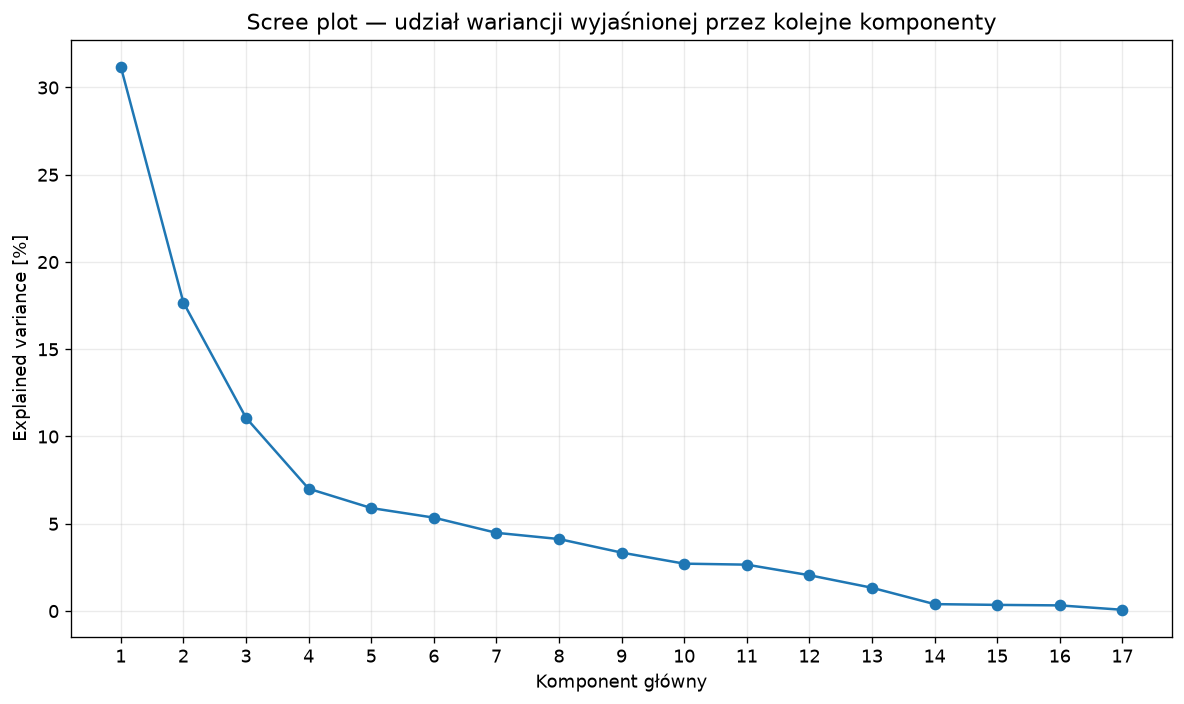

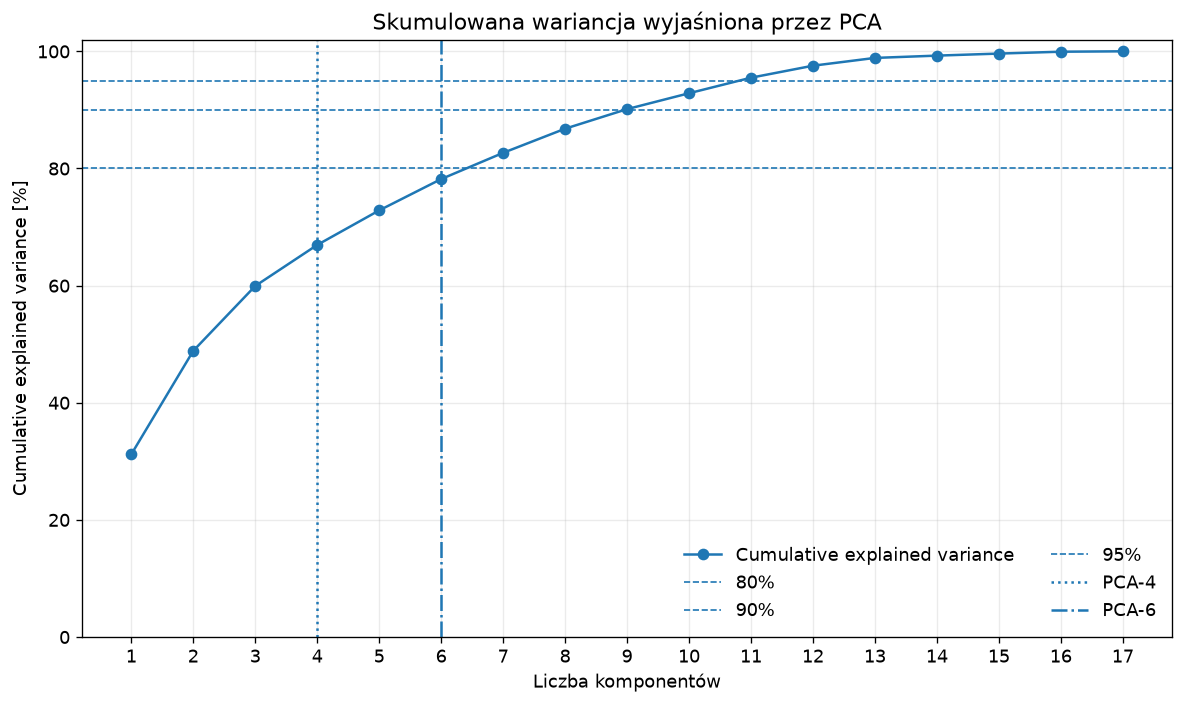

PosixPath('/Users/oskarstachowski/qnn-financial-statement-analysis/reports/pca_diagnostics_for_qnn/figures/02_cumulative_explained_variance.png')

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    np.arange(1, 18),
    100.0 * explained_variance_ratio,
    marker="o",
)
ax.set_title("Scree plot — udział wariancji wyjaśnionej przez kolejne komponenty")
ax.set_xlabel("Komponent główny")
ax.set_ylabel("Explained variance [%]")
ax.set_xticks(np.arange(1, 18))
finalize_figure(fig, "01_scree_plot_explained_variance.png")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    np.arange(1, 18),
    100.0 * cumulative_explained_variance,
    marker="o",
    label="Cumulative explained variance",
)
for threshold in (80.0, 90.0, 95.0):
    ax.axhline(threshold, linestyle="--", linewidth=1, label=f"{threshold:.0f}%")
ax.axvline(4, linestyle=":", linewidth=1.5, label="PCA-4")
ax.axvline(6, linestyle="-.", linewidth=1.5, label="PCA-6")
ax.set_title("Skumulowana wariancja wyjaśniona przez PCA")
ax.set_xlabel("Liczba komponentów")
ax.set_ylabel("Cumulative explained variance [%]")
ax.set_xticks(np.arange(1, 18))
ax.set_ylim(0, 102)
ax.legend(ncol=2)
finalize_figure(fig, "02_cumulative_explained_variance.png")

## 4.2. Porównanie PCA-4 i PCA-6

Porównanie opisuje kompromis **mniejszy wymiar wejściowy ↔ większa utrata informacji**. Nie jest regułą wyboru wariantu i nie pozwala stwierdzić, że jeden wariant jest lepszy predykcyjnie.

In [6]:
pca_models: dict[int, PCA] = {}
pca_scores: dict[int, np.ndarray] = {}
for n_components in (4, 6):
    model = PCA(n_components=n_components, svd_solver="full", whiten=False)
    scores = model.fit_transform(pca_input)
    pca_models[n_components] = model
    pca_scores[n_components] = scores

comparison_rows = []
for n_components, model in pca_models.items():
    retained_ratio = float(model.explained_variance_ratio_.sum())
    comparison_rows.append(
        {
            "Wariant": f"PCA-{n_components}",
            "Liczba komponentów": n_components,
            "Wymiar przed redukcją": 17,
            "Wymiar po redukcji": n_components,
            "Usunięte wymiary": 17 - n_components,
            "Redukcja wymiarowości [%]": 100.0 * (17 - n_components) / 17,
            "Współczynnik kompresji 17/k": 17 / n_components,
            "Zachowana wariancja": retained_ratio,
            "Zachowana wariancja [%]": 100.0 * retained_ratio,
            "Utracona wariancja": 1.0 - retained_ratio,
            "Utracona wariancja [%]": 100.0 * (1.0 - retained_ratio),
        }
    )
pca_comparison = pd.DataFrame(comparison_rows).set_index("Wariant")

save_table(pca_comparison, "09_pca4_vs_pca6_variance_comparison.csv")
show_table("PCA-4 vs PCA-6 — redukcja wymiarowości i wariancja", pca_comparison)

#### PCA-4 vs PCA-6 — redukcja wymiarowości i wariancja

,Liczba komponentów,Wymiar przed redukcją,Wymiar po redukcji,Usunięte wymiary,Redukcja wymiarowości [%],Współczynnik kompresji 17/k,Zachowana wariancja,Zachowana wariancja [%],Utracona wariancja,Utracona wariancja [%]
Wariant,,,,,,,,,,
PCA-4,4,17,4,13,76.470588,4.250000,0.669378,66.937779,0.330622,33.062221
PCA-6,6,17,6,11,64.705882,2.833333,0.781847,78.184737,0.218153,21.815263


## 4.3. Reconstruction error

Dla PCA-4 i PCA-6 dane są transformowane do przestrzeni komponentów, a następnie rekonstruowane przez `inverse_transform`. Błąd rekonstrukcji jest miarą kompresji informacji w przestrzeni wejściowej po preprocessingu, a nie miarą jakości klasyfikatora.

#### Błąd rekonstrukcji PCA-4 i PCA-6

,Mean squared reconstruction error,Root mean squared reconstruction error,Relative squared Frobenius error,Relative Frobenius error,Lost explained variance ratio,Difference: relative squared error - lost variance
Wariant,,,,,,
PCA-4,0.330622,0.574998,0.330622,0.574998,0.330622,0.000000
PCA-6,0.218153,0.467068,0.218153,0.467068,0.218153,-0.000000


#### Błąd rekonstrukcji według cechy

,Wariant,Feature,Block,Feature reconstruction MSE
16,PCA-4,revenue_growth_1y,R,0.769323
15,PCA-4,asset_turnover_t,R,0.665961
3,PCA-4,current_ratio_t,L,0.587696
10,PCA-4,current_ratio_change_1y,D,0.527345
7,PCA-4,asset_growth_1y,D,0.420910
8,PCA-4,delta_roa_1y,D,0.402431
9,PCA-4,delta_ocf_to_assets_1y,D,0.391125
11,PCA-4,delta_liabilities_to_assets_1y,D,0.364735
2,PCA-4,ocf_to_assets_t,L,0.265100
6,PCA-4,accruals_to_assets_t,L,0.207880


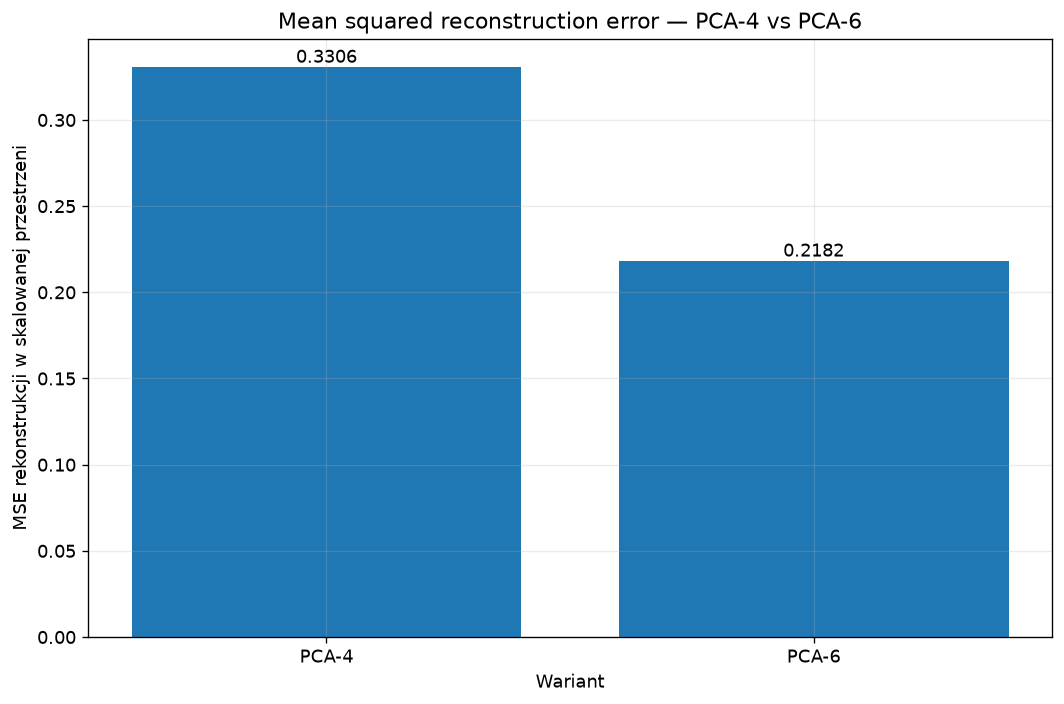

PosixPath('/Users/oskarstachowski/qnn-financial-statement-analysis/reports/pca_diagnostics_for_qnn/figures/03_reconstruction_error_comparison.png')

In [7]:
x_scaled = pca_input.to_numpy(dtype=float)
reconstruction_rows = []
reconstruction_by_feature_rows = []
reconstructed_matrices: dict[int, np.ndarray] = {}

for n_components, model in pca_models.items():
    scores = pca_scores[n_components]
    reconstructed = model.inverse_transform(scores)
    reconstructed_matrices[n_components] = reconstructed
    residual = x_scaled - reconstructed
    squared_error = residual**2
    mse = float(np.mean(squared_error))
    rmse = float(np.sqrt(mse))
    total_centered_energy = float(np.sum((x_scaled - model.mean_) ** 2))
    residual_energy = float(np.sum(squared_error))
    relative_squared_frobenius_error = residual_energy / total_centered_energy
    relative_frobenius_error = math.sqrt(relative_squared_frobenius_error)
    lost_variance_ratio = 1.0 - float(model.explained_variance_ratio_.sum())

    reconstruction_rows.append(
        {
            "Wariant": f"PCA-{n_components}",
            "Mean squared reconstruction error": mse,
            "Root mean squared reconstruction error": rmse,
            "Relative squared Frobenius error": relative_squared_frobenius_error,
            "Relative Frobenius error": relative_frobenius_error,
            "Lost explained variance ratio": lost_variance_ratio,
            "Difference: relative squared error - lost variance": (
                relative_squared_frobenius_error - lost_variance_ratio
            ),
        }
    )

    feature_mse = pd.Series(np.mean(squared_error, axis=0), index=FEATURES)
    for feature in FEATURES:
        reconstruction_by_feature_rows.append(
            {
                "Wariant": f"PCA-{n_components}",
                "Feature": feature,
                "Block": FEATURE_TO_BLOCK[feature],
                "Feature reconstruction MSE": float(feature_mse[feature]),
            }
        )

reconstruction_metrics = pd.DataFrame(reconstruction_rows).set_index("Wariant")
reconstruction_by_feature = pd.DataFrame(reconstruction_by_feature_rows).set_index(
    ["Wariant", "Feature"]
)

save_table(reconstruction_metrics, "10_reconstruction_metrics.csv")
save_table(reconstruction_by_feature, "11_reconstruction_error_by_feature.csv")

show_table("Błąd rekonstrukcji PCA-4 i PCA-6", reconstruction_metrics)
show_table(
    "Błąd rekonstrukcji według cechy",
    reconstruction_by_feature.reset_index().sort_values(
        ["Wariant", "Feature reconstruction MSE"], ascending=[True, False]
    ),
)

fig, ax = plt.subplots(figsize=(9, 6))
plot_values = reconstruction_metrics["Mean squared reconstruction error"]
ax.bar(plot_values.index, plot_values.values)
ax.set_title("Mean squared reconstruction error — PCA-4 vs PCA-6")
ax.set_xlabel("Wariant")
ax.set_ylabel("MSE rekonstrukcji w skalowanej przestrzeni")
for position, value in enumerate(plot_values.values):
    ax.text(position, value, f"{value:.4f}", ha="center", va="bottom")
finalize_figure(fig, "03_reconstruction_error_comparison.png")

## 4.4. Współczynniki komponentów i loadings

Notebook rozróżnia dwa pojęcia:

- **współczynniki komponentów / eigenvectors**: elementy `PCA.components_`;
- **loadings** używane poniżej:  
  \[
  loading_{j,k}=v_{j,k}\sqrt{\lambda_k},
  \]
  gdzie \(v_{j,k}\) jest współczynnikiem cechy \(j\) w komponencie \(k\), a \(\lambda_k\) jest wartością własną komponentu.

`components_` nie są automatycznie nazywane korelacjami cech z komponentami. Ponieważ wejście jest standaryzowane, zastosowane loadings mają intuicyjną interpretację siły wkładu, lecz w notebooku nie są raportowane jako współczynniki korelacji.

In [8]:
first_six = [f"PC{i}" for i in range(1, 7)]
component_coefficients = pd.DataFrame(
    pca_full.components_[:6].T,
    index=pd.Index(FEATURES, name="Feature"),
    columns=first_six,
)
loadings = component_coefficients.multiply(
    np.sqrt(pca_full.explained_variance_[:6]), axis="columns"
)

ranking_rows = []
for component in first_six:
    ordered_features = loadings[component].abs().sort_values(ascending=False).head(3).index
    for rank, feature in enumerate(ordered_features, start=1):
        loading_value = float(loadings.loc[feature, component])
        coefficient_value = float(component_coefficients.loc[feature, component])
        ranking_rows.append(
            {
                "Component": component,
                "Rank": rank,
                "Feature": feature,
                "Block": FEATURE_TO_BLOCK[feature],
                "Loading": loading_value,
                "Abs loading": abs(loading_value),
                "Sign": "dodatni" if loading_value > 0 else "ujemny" if loading_value < 0 else "zero",
                "Component coefficient": coefficient_value,
            }
        )
top_loadings = pd.DataFrame(ranking_rows).set_index(["Component", "Rank"])

save_table(component_coefficients, "12_component_coefficients_pc1_pc6.csv")
save_table(loadings, "13_loadings_pc1_pc6.csv")
save_table(top_loadings, "14_top3_absolute_loadings_per_component.csv")

show_table("Współczynniki `components_` — PC1–PC6", component_coefficients)
show_table("Loadings według przyjętej definicji — PC1–PC6", loadings)
show_table("Trzy największe |loading| dla każdego komponentu", top_loadings)

#### Współczynniki `components_` — PC1–PC6

,PC1,PC2,PC3,PC4,PC5,PC6
Feature,,,,,,
log_assets_t,0.291039,-0.152860,-0.014218,0.508339,-0.333029,0.008725
roa_t,0.401249,0.042431,-0.082558,-0.085975,0.163745,0.080434
ocf_to_assets_t,0.372107,0.001823,-0.001030,0.026653,0.054074,0.016306
current_ratio_t,0.067700,0.154452,-0.297862,-0.354066,-0.335546,-0.470288
liabilities_to_assets_t,-0.362491,-0.067810,0.230976,0.148040,-0.063153,-0.077649
working_capital_to_assets_t,0.359600,0.070632,-0.233092,-0.172018,0.064156,0.050248
accruals_to_assets_t,0.373979,0.049714,-0.113052,-0.126923,0.187136,0.094437
asset_growth_1y,-0.036032,0.417471,0.158157,0.035109,-0.219078,-0.022932
delta_roa_1y,0.100748,0.377009,0.221405,0.143191,0.220169,0.097333


#### Loadings według przyjętej definicji — PC1–PC6

,PC1,PC2,PC3,PC4,PC5,PC6
Feature,,,,,,
log_assets_t,0.670123,-0.264975,-0.019506,0.554858,-0.333488,0.008320
roa_t,0.923886,0.073552,-0.113262,-0.093843,0.163971,0.076701
ocf_to_assets_t,0.856784,0.003160,-0.001414,0.029092,0.054149,0.015549
current_ratio_t,0.155881,0.267735,-0.408640,-0.386468,-0.336008,-0.448458
liabilities_to_assets_t,-0.834644,-0.117546,0.316879,0.161587,-0.063240,-0.074045
working_capital_to_assets_t,0.827987,0.122436,-0.319782,-0.187759,0.064245,0.047916
accruals_to_assets_t,0.861096,0.086176,-0.155098,-0.138538,0.187394,0.090054
asset_growth_1y,-0.082964,0.723664,0.216977,0.038322,-0.219380,-0.021868
delta_roa_1y,0.231975,0.653525,0.303748,0.156295,0.220472,0.092815


#### Trzy największe |loading| dla każdego komponentu

Feature Block   Loading  Abs loading     Sign  Component coefficient
Component Rank                                                                                             
PC1       1                              roa_t     L  0.923886     0.923886  dodatni               0.401249
          2               accruals_to_assets_t     L  0.861096     0.861096  dodatni               0.373979
          3                    ocf_to_assets_t     L  0.856784     0.856784  dodatni               0.372107
PC2       1                    asset_growth_1y     D  0.723664     0.723664  dodatni               0.417471
          2     delta_liabilities_to_assets_1y     D -0.693792     0.693792   ujemny              -0.400238
          3            current_ratio_change_1y     D  0.671425     0.671425  dodatni               0.387335
PC3       1                       ocf_margin_t     R  0.687778     0.687778  dodatni               0.501328
          2                    profit_margin_t     R  0.621962     0.621962  dodatni               0.453354
          3                   asset_turnover_t     R  0.470291     0.470291  dodatni               0.342799
PC4       1                       log_assets_t     L  0.554858     0.554858  dodatni               0.508339
          2                   log1p_revenues_t     R  0.464385     0.464385  dodatni               0.425452
          3                    current_ratio_t     L -0.386468     0.386468   ujemny              -0.354066
PC5       1                   asset_turnover_t     R  0.499818     0.499818  dodatni               0.499130
          2                  revenue_growth_1y     R -0.425661     0.425661   ujemny              -0.425075
          3                    current_ratio_t     L -0.336008     0.336008   ujemny              -0.335546
PC6       1                  revenue_growth_1y     R  0.701738     0.701738  dodatni               0.735896
          2                    current_ratio_t     L -0.448458     0.448458   ujemny              -0.470288
          3            current_ratio_change_1y     D -0.378641     0.378641   ujemny              -0.397072

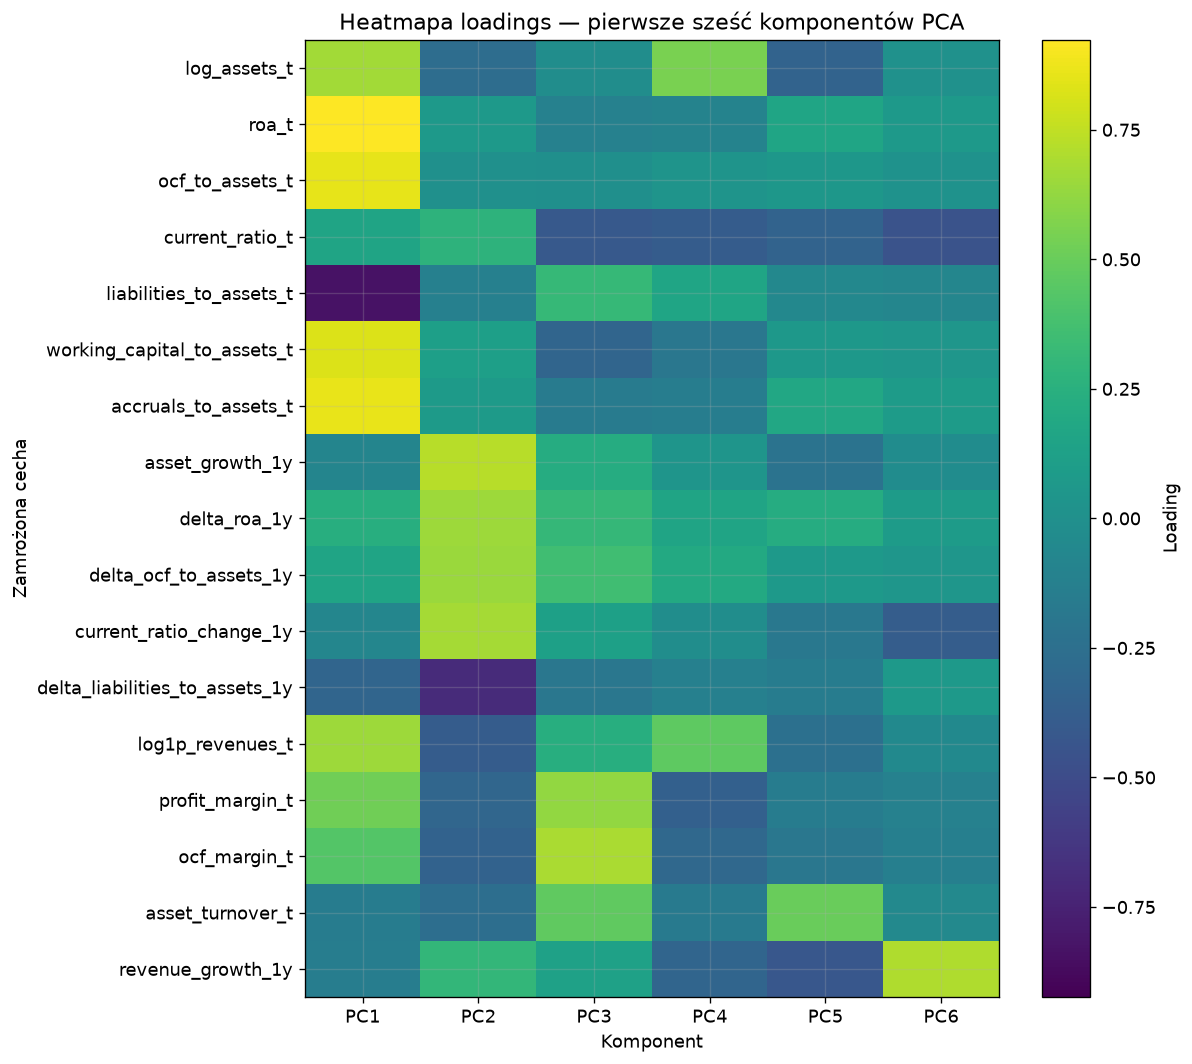

PosixPath('/Users/oskarstachowski/qnn-financial-statement-analysis/reports/pca_diagnostics_for_qnn/figures/04_loadings_heatmap_pc1_pc6.png')

In [9]:
fig, ax = plt.subplots(figsize=(10, 9))
loading_array = loadings.to_numpy(dtype=float)
limit = float(np.nanmax(np.abs(loading_array)))
image = ax.imshow(loading_array, aspect="auto", vmin=-limit, vmax=limit)
ax.set_title("Heatmapa loadings — pierwsze sześć komponentów PCA")
ax.set_xlabel("Komponent")
ax.set_ylabel("Zamrożona cecha")
ax.set_xticks(np.arange(len(first_six)), labels=first_six)
ax.set_yticks(np.arange(len(FEATURES)), labels=FEATURES)
fig.colorbar(image, ax=ax, label="Loading")
finalize_figure(fig, "04_loadings_heatmap_pc1_pc6.png")

## 4.5. Interpretacja struktury komponentów

Poniższe opisy są generowane wyłącznie na podstawie największych wartości bezwzględnych loadings. Komponentom nie są przypisywane arbitralne nazwy ekonomiczne. Znak całego komponentu PCA jest arbitralny i może zostać odwrócony bez zmiany rozwiązania matematycznego.

In [10]:
def component_structure_markdown(component: str) -> str:
    subset = top_loadings.loc[component].sort_index()
    entries = []
    for _, row in subset.iterrows():
        entries.append(f"`{row['Feature']}` ({row['Loading']:+.4f})")
    signs = subset["Sign"].tolist()
    if len(set(signs)) == 1:
        relation = (
            "Trzy dominujące cechy mają w wybranej orientacji ten sam znak, "
            "co opisuje wspólny kierunek ich zmienności w tym komponencie."
        )
    else:
        relation = (
            "Wśród dominujących cech występują przeciwne znaki, więc komponent "
            "opisuje przede wszystkim kontrast pomiędzy odpowiadającymi im wzorcami zmienności."
        )
    return (
        f"**{component}.** Największe `|loading|`: {', '.join(entries)}. {relation} "
        "Znak całego komponentu jest arbitralny; interpretowana jest przede wszystkim "
        "wartość bezwzględna i wzajemna struktura cech."
    )


component_interpretation_lines = [component_structure_markdown(pc) for pc in first_six]
component_interpretation_markdown = "\n\n".join(component_interpretation_lines)

if SAVE_OUTPUTS:
    (OUTPUT_ROOT / "component_structure_interpretation.md").write_text(
        component_interpretation_markdown + "\n", encoding="utf-8"
    )

display(Markdown(component_interpretation_markdown))

**PC1.** Największe `|loading|`: `roa_t` (+0.9239), `accruals_to_assets_t` (+0.8611), `ocf_to_assets_t` (+0.8568). Trzy dominujące cechy mają w wybranej orientacji ten sam znak, co opisuje wspólny kierunek ich zmienności w tym komponencie. Znak całego komponentu jest arbitralny; interpretowana jest przede wszystkim wartość bezwzględna i wzajemna struktura cech.

**PC2.** Największe `|loading|`: `asset_growth_1y` (+0.7237), `delta_liabilities_to_assets_1y` (-0.6938), `current_ratio_change_1y` (+0.6714). Wśród dominujących cech występują przeciwne znaki, więc komponent opisuje przede wszystkim kontrast pomiędzy odpowiadającymi im wzorcami zmienności. Znak całego komponentu jest arbitralny; interpretowana jest przede wszystkim wartość bezwzględna i wzajemna struktura cech.

**PC3.** Największe `|loading|`: `ocf_margin_t` (+0.6878), `profit_margin_t` (+0.6220), `asset_turnover_t` (+0.4703). Trzy dominujące cechy mają w wybranej orientacji ten sam znak, co opisuje wspólny kierunek ich zmienności w tym komponencie. Znak całego komponentu jest arbitralny; interpretowana jest przede wszystkim wartość bezwzględna i wzajemna struktura cech.

**PC4.** Największe `|loading|`: `log_assets_t` (+0.5549), `log1p_revenues_t` (+0.4644), `current_ratio_t` (-0.3865). Wśród dominujących cech występują przeciwne znaki, więc komponent opisuje przede wszystkim kontrast pomiędzy odpowiadającymi im wzorcami zmienności. Znak całego komponentu jest arbitralny; interpretowana jest przede wszystkim wartość bezwzględna i wzajemna struktura cech.

**PC5.** Największe `|loading|`: `asset_turnover_t` (+0.4998), `revenue_growth_1y` (-0.4257), `current_ratio_t` (-0.3360). Wśród dominujących cech występują przeciwne znaki, więc komponent opisuje przede wszystkim kontrast pomiędzy odpowiadającymi im wzorcami zmienności. Znak całego komponentu jest arbitralny; interpretowana jest przede wszystkim wartość bezwzględna i wzajemna struktura cech.

**PC6.** Największe `|loading|`: `revenue_growth_1y` (+0.7017), `current_ratio_t` (-0.4485), `current_ratio_change_1y` (-0.3786). Wśród dominujących cech występują przeciwne znaki, więc komponent opisuje przede wszystkim kontrast pomiędzy odpowiadającymi im wzorcami zmienności. Znak całego komponentu jest arbitralny; interpretowana jest przede wszystkim wartość bezwzględna i wzajemna struktura cech.

## 4.6. PCA-4 vs PCA-6 — struktura zachowanej informacji

PCA-4 i PCA-6 mają wspólne komponenty PC1–PC4. Wariant sześciowymiarowy zachowuje dodatkowo dwa ortogonalne kierunki zmienności: PC5 i PC6. Analiza poniżej opisuje te kierunki, ale nie zakłada, że są one użyteczne predykcyjnie.

In [11]:
extra_component_rows = []
for component_number in (5, 6):
    component = f"PC{component_number}"
    subset = top_loadings.loc[component].sort_index()
    dominant = ", ".join(
        f"{row['Feature']} ({row['Loading']:+.4f})" for _, row in subset.iterrows()
    )
    extra_component_rows.append(
        {
            "Component": component,
            "Explained variance ratio": explained_variance_ratio[component_number - 1],
            "Explained variance [%]": 100.0 * explained_variance_ratio[component_number - 1],
            "Dominant features": dominant,
        }
    )
extra_components = pd.DataFrame(extra_component_rows).set_index("Component")
additional_variance_pc5_pc6 = float(explained_variance_ratio[4:6].sum())

pca4_pca6_structure = pd.DataFrame(
    {
        "wartosc": [
            "PC1–PC4",
            "PC5–PC6",
            additional_variance_pc5_pc6,
            100.0 * additional_variance_pc5_pc6,
            float(cumulative_explained_variance[3]),
            float(cumulative_explained_variance[5]),
        ]
    },
    index=[
        "komponenty wspólne PCA-4 i PCA-6",
        "komponenty dodatkowe PCA-6",
        "dodatkowa wariancja PC5+PC6",
        "dodatkowa wariancja PC5+PC6 [%]",
        "cumulative variance PCA-4",
        "cumulative variance PCA-6",
    ],
)

save_table(extra_components, "15_pc5_pc6_information_structure.csv")
save_table(pca4_pca6_structure, "16_pca4_pca6_structure_summary.csv")

show_table("PC5 i PC6 — dodatkowa struktura informacji", extra_components)
show_table("PCA-4 vs PCA-6 — komponenty wspólne i dodatkowe", pca4_pca6_structure)

display(
    Markdown(
        "PCA-4 pomija dwa ortogonalne wzorce zmienności opisane przez PC5 i PC6. "
        "Rodzaj pominiętej informacji jest scharakteryzowany przez dominujące cechy "
        "w tabeli powyżej. Sam fakt zachowania dodatkowej wariancji przez PCA-6 nie "
        "oznacza, że PC5–PC6 poprawią rozróżnianie klas targetu."
    )
)

#### PC5 i PC6 — dodatkowa struktura informacji

,Explained variance ratio,Explained variance [%],Dominant features
Component,,,
PC5,0.058983,5.898286,"asset_turnover_t (+0.4998), revenue_growth_1y (-0.4257), current_ratio_t (-0.3360)"
PC6,0.053487,5.348672,"revenue_growth_1y (+0.7017), current_ratio_t (-0.4485), current_ratio_change_1y (-0.3786)"


#### PCA-4 vs PCA-6 — komponenty wspólne i dodatkowe

,wartosc
komponenty wspólne PCA-4 i PCA-6,PC1–PC4
komponenty dodatkowe PCA-6,PC5–PC6
dodatkowa wariancja PC5+PC6,0.112470
dodatkowa wariancja PC5+PC6 [%],11.246958
cumulative variance PCA-4,0.669378
cumulative variance PCA-6,0.781847


PCA-4 pomija dwa ortogonalne wzorce zmienności opisane przez PC5 i PC6. Rodzaj pominiętej informacji jest scharakteryzowany przez dominujące cechy w tabeli powyżej. Sam fakt zachowania dodatkowej wariancji przez PCA-6 nie oznacza, że PC5–PC6 poprawią rozróżnianie klas targetu.

## 4.7. Pomocnicza wizualizacja przestrzeni PCA

Target jest używany wyłącznie po dopasowaniu preprocessingu i PCA, jako oznaczenie punktów na projekcjach PC1–PC2 oraz PC1–PC3. Wizualizacja nie uczestniczy w wyborze kierunków PCA i nie jest dowodem jakości późniejszego klasyfikatora.

#### Kontrola wykorzystania targetu wyłącznie po dopasowaniu PCA

,wartosc
N połączenia,19671
target=1,3623
target=0,16048
moment dostępu do etykiety,etykieta wczytana po pca_full.fit
rola targetu,wyłącznie oznaczenie punktów na wykresach


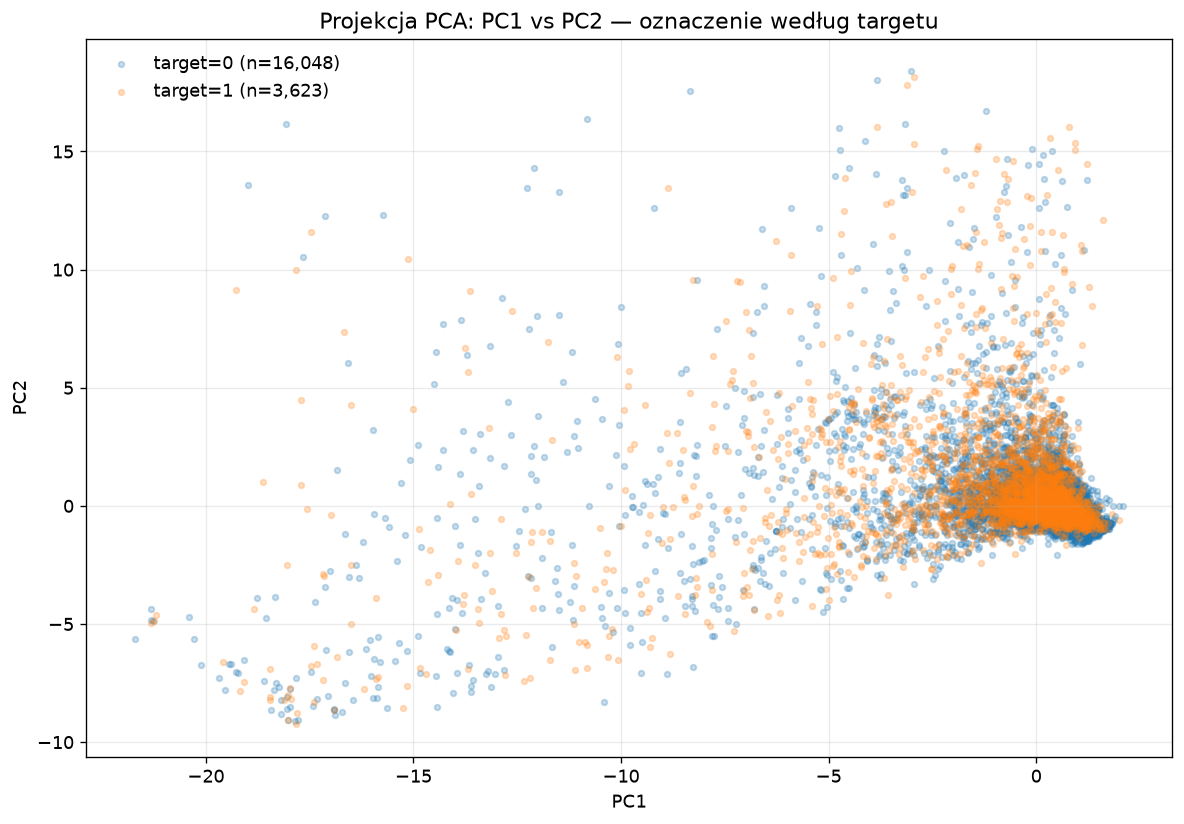

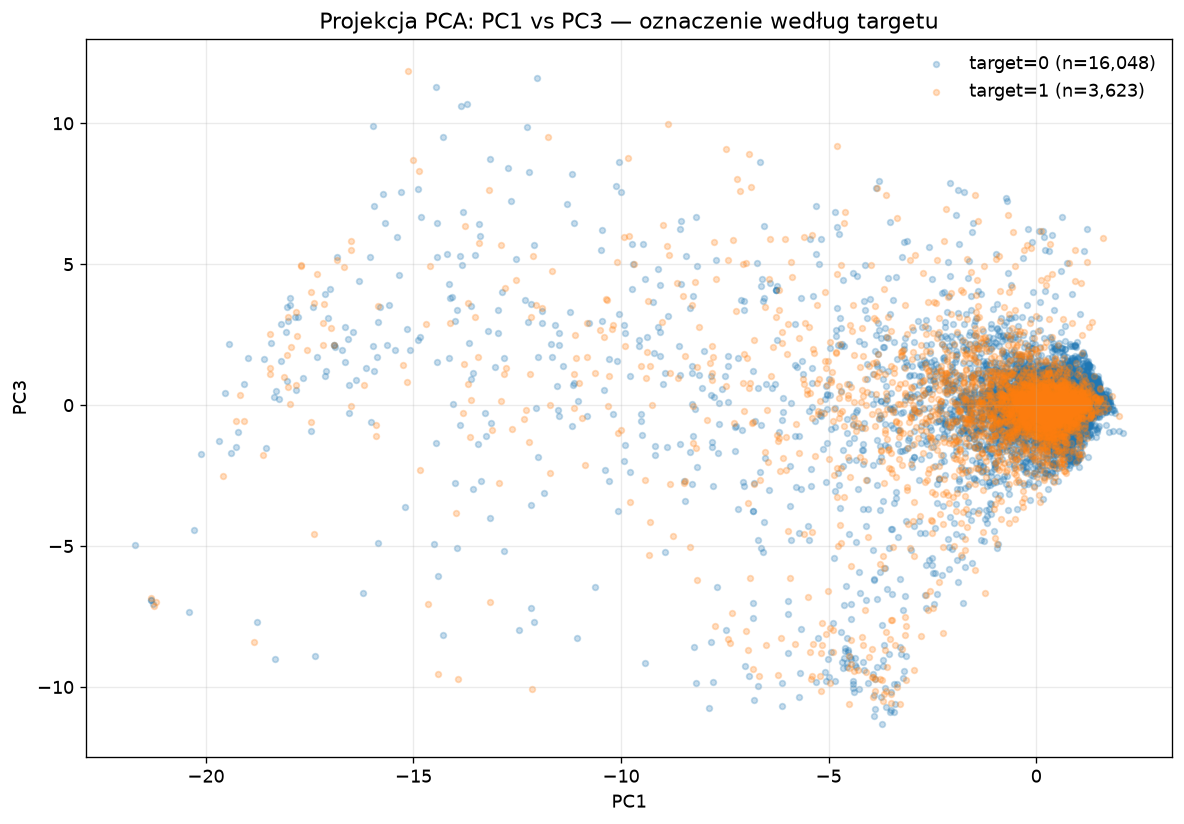

Target został wczytany dopiero po dopasowaniu PCA i wykorzystany wyłącznie do dwóch wykresów projekcyjnych.


In [12]:
TARGET_VISUALIZATION_REQUIRED = [
    "research_universe_company_year_id",
    "feature_year",
    "target_status",
    "target_candidate_v2_pit_b",
]
target_visualization = pd.read_csv(
    PATHS["target_application"],
    usecols=TARGET_VISUALIZATION_REQUIRED,
    dtype={"research_universe_company_year_id": "string"},
    low_memory=False,
)
target_visualization["feature_year"] = assert_year_scope(
    target_visualization, "target labels loaded after PCA fit"
)
target_visualization["target_candidate_v2_pit_b"] = pd.to_numeric(
    target_visualization["target_candidate_v2_pit_b"], errors="raise"
)
if target_visualization["research_universe_company_year_id"].duplicated().any():
    raise RuntimeError("Target do wizualizacji ma zduplikowane ID company-year.")

target_for_plot = analysis_frame[
    ["research_universe_company_year_id", "feature_year"]
].merge(
    target_visualization.rename(columns={"feature_year": "target_feature_year"}),
    on="research_universe_company_year_id",
    how="left",
    validate="one_to_one",
)
if not target_for_plot["feature_year"].eq(target_for_plot["target_feature_year"]).all():
    raise RuntimeError("Niezgodność roku przy dołączaniu targetu po dopasowaniu PCA.")
if not target_for_plot["target_status"].eq("available").all():
    raise RuntimeError("Finalna próba PCA zawiera wiersz bez dostępnego targetu.")
target_for_plot["target"] = target_for_plot["target_candidate_v2_pit_b"].astype(int)
if not target_for_plot["target"].isin([0, 1]).all():
    raise RuntimeError("Target przyjmuje wartości inne niż 0/1.")

expected_positive_n = int(current_config["supervised_sample"]["class_balance"]["positive_n"])
expected_negative_n = int(current_config["supervised_sample"]["class_balance"]["negative_n"])
if int(target_for_plot["target"].sum()) != expected_positive_n:
    raise RuntimeError("Niezgodna liczba obserwacji target=1.")
if int(target_for_plot["target"].eq(0).sum()) != expected_negative_n:
    raise RuntimeError("Niezgodna liczba obserwacji target=0.")

target_visualization_control = pd.DataFrame(
    {
        "wartosc": [
            len(target_for_plot),
            expected_positive_n,
            expected_negative_n,
            "etykieta wczytana po pca_full.fit",
            "wyłącznie oznaczenie punktów na wykresach",
        ]
    },
    index=[
        "N połączenia",
        "target=1",
        "target=0",
        "moment dostępu do etykiety",
        "rola targetu",
    ],
)
save_table(target_visualization_control, "17_target_visualization_control.csv")
show_table("Kontrola wykorzystania targetu wyłącznie po dopasowaniu PCA", target_visualization_control)

full_scores = pca_full.transform(pca_input)
score_frame = pd.DataFrame(
    full_scores[:, :3],
    columns=["PC1", "PC2", "PC3"],
    index=analysis_frame.index,
)
score_frame["target"] = target_for_plot["target"].to_numpy(dtype=int)

for x_component, y_component, filename in (
    ("PC1", "PC2", "05_pca_projection_pc1_pc2_by_target.png"),
    ("PC1", "PC3", "06_pca_projection_pc1_pc3_by_target.png"),
):
    fig, ax = plt.subplots(figsize=(10, 7))
    for target_value in (0, 1):
        subset = score_frame.loc[score_frame["target"].eq(target_value)]
        ax.scatter(
            subset[x_component],
            subset[y_component],
            s=12,
            alpha=0.25,
            label=f"target={target_value} (n={len(subset):,})",
            rasterized=True,
        )
    ax.set_title(f"Projekcja PCA: {x_component} vs {y_component} — oznaczenie według targetu")
    ax.set_xlabel(x_component)
    ax.set_ylabel(y_component)
    ax.legend()
    finalize_figure(fig, filename)

print(
    "Target został wczytany dopiero po dopasowaniu PCA i wykorzystany wyłącznie "
    "do dwóch wykresów projekcyjnych."
)

## 4.8. Podsumowanie PCA

Podsumowanie jest generowane automatycznie z wyników obliczeń. Ma charakter materiału pomocniczego do opisu metody w pracy magisterskiej i nie podejmuje decyzji o wyborze wariantu modelowego.

In [13]:
def top_features_text(component: str) -> str:
    subset = top_loadings.loc[component].sort_index()
    return ", ".join(
        f"`{row['Feature']}` ({row['Loading']:+.3f})" for _, row in subset.iterrows()
    )


pca4_retained = float(pca_comparison.loc["PCA-4", "Zachowana wariancja"])
pca6_retained = float(pca_comparison.loc["PCA-6", "Zachowana wariancja"])
pca4_lost = 1.0 - pca4_retained
pca6_lost = 1.0 - pca6_retained
pca4_mse = float(
    reconstruction_metrics.loc["PCA-4", "Mean squared reconstruction error"]
)
pca6_mse = float(
    reconstruction_metrics.loc["PCA-6", "Mean squared reconstruction error"]
)
reconstruction_improvement = pca4_mse - pca6_mse
threshold_text = "; ".join(
    f"{threshold:.0f}%: {int(row['minimum_components'])} komponentów"
    for threshold, row in variance_thresholds.iterrows()
)
component_text = "\n".join(
    f"   - **{pc}:** {top_features_text(pc)}" for pc in first_six
)
production_mismatch_text = (
    "Aktualny zamrożony kontrakt QNN kieruje do PCA także wskaźniki braków, więc "
    "17-cechowe wyniki diagnostyczne nie są numeryczną kopią produkcyjnej reprezentacji."
    if production_includes_missing_indicators
    else "Zakres diagnostyczny jest zgodny z liczbą kolumn wejściowych produkcyjnego PCA."
)

summary_markdown = f"""
### Podsumowanie diagnostycznej analizy PCA — train 2011–2020

1. **Narastanie wariancji.** Minimalna liczba komponentów potrzebna do przekroczenia progów opisowych wynosi: {threshold_text}. Progi nie stanowią automatycznej reguły wyboru wymiaru.

2. **PCA-4.** Wariant czterowymiarowy zachowuje **{100.0 * pca4_retained:.2f}%** wariancji i traci **{100.0 * pca4_lost:.2f}%**. Redukuje wejście z 17 do 4 wymiarów, czyli usuwa {17 - 4} wymiarów ({100.0 * (17 - 4) / 17:.2f}%).

3. **PCA-6.** Wariant sześciowymiarowy zachowuje **{100.0 * pca6_retained:.2f}%** wariancji i traci **{100.0 * pca6_lost:.2f}%**. Redukuje wejście z 17 do 6 wymiarów, czyli usuwa {17 - 6} wymiarów ({100.0 * (17 - 6) / 17:.2f}%).

4. **Błąd rekonstrukcji.** MSE rekonstrukcji wynosi **{pca4_mse:.6f}** dla PCA-4 oraz **{pca6_mse:.6f}** dla PCA-6. Dodanie PC5 i PC6 zmniejsza MSE o **{reconstruction_improvement:.6f}**. Jest to diagnostyka kompresji, a nie jakości klasyfikacji.

5. **Struktura PC1–PC6.** Największe bezwzględne loadings tworzą następujące zestawy:
{component_text}

6. **Dodatkowa informacja PC5–PC6.** PC5 i PC6 zachowują łącznie dodatkowe **{100.0 * additional_variance_pc5_pc6:.2f}%** wariancji. Pominięta przez PCA-4 struktura odpowiada wzorcom cech wymienionym dla PC5 i PC6; nie oznacza to automatycznej użyteczności predykcyjnej.

7. **Kompromis.** PCA-4 zapewnia silniejszą kompresję i wejście odpowiadające 4 kubitom, natomiast PCA-6 zachowuje większą część wariancji kosztem dwóch dodatkowych wymiarów i 6 kubitów. Ostateczne porównanie musi zostać wykonane w leakage-safe walidacji modeli.

8. **Ograniczenia interpretacyjne.** PCA maksymalizuje wariancję wejścia, a nie rozdzielność `target=0/1`; znak komponentu jest arbitralny; loadings nie dowodzą zależności przyczynowych ani przydatności predykcyjnej; analiza dotyczy warunkowej, zamrożonej próby supervised 2011–2020. {production_mismatch_text}

9. **Granica wykorzystania.** Obiekty preprocessingu i PCA dopasowane w tym notebooku nie są zapisywane. W finalnym eksperymencie imputer, scaler, PCA i model muszą być fitowane wyłącznie na części treningowej każdego folda, a walidacja może być jedynie transformowana.
""".strip()

if SAVE_OUTPUTS:
    (OUTPUT_ROOT / "pca_summary.md").write_text(summary_markdown + "\n", encoding="utf-8")

reproducibility = pd.DataFrame(
    {
        "wartosc": [
            sys.version.split()[0],
            pd.__version__,
            np.__version__,
            sklearn.__version__,
            current_config["supervised_ml_pipeline"]["version"],
            str(PATHS["x_t"].relative_to(ROOT)),
            fingerprints["x_t"]["sha256"],
            str(PATHS["target_application"].relative_to(ROOT)),
            fingerprints["target_application"]["sha256"],
            RANDOM_SEED,
            YEAR_MIN,
            YEAR_MAX,
            len(FEATURES),
            "full",
            False,
            "nie zapisano",
        ]
    },
    index=[
        "Python",
        "pandas",
        "numpy",
        "scikit-learn",
        "pipeline overlay",
        "X_t artifact",
        "X_t SHA-256",
        "target-application artifact",
        "target-application SHA-256",
        "random seed",
        "minimalny rok PCA",
        "maksymalny rok PCA",
        "liczba wejściowych cech",
        "PCA svd_solver",
        "PCA whiten",
        "serializacja dopasowanego PCA",
    ],
)
save_table(reproducibility, "18_reproducibility.csv")

display(Markdown(summary_markdown))
show_table("Informacje reprodukowalności", reproducibility)

if SAVE_OUTPUTS:
    table_count = len(list(TABLE_DIR.glob("*.csv")))
    figure_count = len(list(FIGURE_DIR.glob("*.png")))
    print(
        f"Zapisano {table_count} tabel CSV, {figure_count} wykresów PNG oraz "
        f"podsumowania Markdown w {OUTPUT_ROOT.relative_to(ROOT)}."
    )

### Podsumowanie diagnostycznej analizy PCA — train 2011–2020

1. **Narastanie wariancji.** Minimalna liczba komponentów potrzebna do przekroczenia progów opisowych wynosi: 80%: 7 komponentów; 90%: 9 komponentów; 95%: 11 komponentów. Progi nie stanowią automatycznej reguły wyboru wymiaru.

2. **PCA-4.** Wariant czterowymiarowy zachowuje **66.94%** wariancji i traci **33.06%**. Redukuje wejście z 17 do 4 wymiarów, czyli usuwa 13 wymiarów (76.47%).

3. **PCA-6.** Wariant sześciowymiarowy zachowuje **78.18%** wariancji i traci **21.82%**. Redukuje wejście z 17 do 6 wymiarów, czyli usuwa 11 wymiarów (64.71%).

4. **Błąd rekonstrukcji.** MSE rekonstrukcji wynosi **0.330622** dla PCA-4 oraz **0.218153** dla PCA-6. Dodanie PC5 i PC6 zmniejsza MSE o **0.112470**. Jest to diagnostyka kompresji, a nie jakości klasyfikacji.

5. **Struktura PC1–PC6.** Największe bezwzględne loadings tworzą następujące zestawy:
   - **PC1:** `roa_t` (+0.924), `accruals_to_assets_t` (+0.861), `ocf_to_assets_t` (+0.857)
   - **PC2:** `asset_growth_1y` (+0.724), `delta_liabilities_to_assets_1y` (-0.694), `current_ratio_change_1y` (+0.671)
   - **PC3:** `ocf_margin_t` (+0.688), `profit_margin_t` (+0.622), `asset_turnover_t` (+0.470)
   - **PC4:** `log_assets_t` (+0.555), `log1p_revenues_t` (+0.464), `current_ratio_t` (-0.386)
   - **PC5:** `asset_turnover_t` (+0.500), `revenue_growth_1y` (-0.426), `current_ratio_t` (-0.336)
   - **PC6:** `revenue_growth_1y` (+0.702), `current_ratio_t` (-0.448), `current_ratio_change_1y` (-0.379)

6. **Dodatkowa informacja PC5–PC6.** PC5 i PC6 zachowują łącznie dodatkowe **11.25%** wariancji. Pominięta przez PCA-4 struktura odpowiada wzorcom cech wymienionym dla PC5 i PC6; nie oznacza to automatycznej użyteczności predykcyjnej.

7. **Kompromis.** PCA-4 zapewnia silniejszą kompresję i wejście odpowiadające 4 kubitom, natomiast PCA-6 zachowuje większą część wariancji kosztem dwóch dodatkowych wymiarów i 6 kubitów. Ostateczne porównanie musi zostać wykonane w leakage-safe walidacji modeli.

8. **Ograniczenia interpretacyjne.** PCA maksymalizuje wariancję wejścia, a nie rozdzielność `target=0/1`; znak komponentu jest arbitralny; loadings nie dowodzą zależności przyczynowych ani przydatności predykcyjnej; analiza dotyczy warunkowej, zamrożonej próby supervised 2011–2020. Aktualny zamrożony kontrakt QNN kieruje do PCA także wskaźniki braków, więc 17-cechowe wyniki diagnostyczne nie są numeryczną kopią produkcyjnej reprezentacji.

9. **Granica wykorzystania.** Obiekty preprocessingu i PCA dopasowane w tym notebooku nie są zapisywane. W finalnym eksperymencie imputer, scaler, PCA i model muszą być fitowane wyłącznie na części treningowej każdego folda, a walidacja może być jedynie transformowana.

#### Informacje reprodukowalności

,wartosc
Python,3.13.13
pandas,3.0.3
numpy,2.4.6
scikit-learn,1.9.0
pipeline overlay,1.3.0
X_t artifact,data/processed/x_t_pit_v1_1_0_train.csv
X_t SHA-256,872cb551a0855d658c52276e5e7594efb05da167718709ab76b386ebfa917d65
target-application artifact,data/processed/research_universe_pit_v1_1_0_target_pit_b_v1_2_0_train.csv
target-application SHA-256,0f5d3bdefe13ed6ea6a1c6cdc94ae2c663f59175a7363dd8bffa26717069dd1b
random seed,20260818


Zapisano 19 tabel CSV, 6 wykresów PNG oraz podsumowania Markdown w reports/pca_diagnostics_for_qnn.


---

### Krytyczna zasada dla późniejszego modelowania

Ten notebook dopasowuje PCA raz na całej próbie train 2011–2020 **wyłącznie w celu diagnostycznym**. Tak dopasowanego PCA nie wolno użyć w walidacji ani w finalnym treningu modelu.

W każdym foldzie eksperymentu kolejność musi być następująca:

1. dopasowanie winsoryzacji i imputacji wyłącznie na train folda;
2. dopasowanie skalowania wyłącznie na train folda;
3. dopasowanie PCA wyłącznie na train folda;
4. transformacja validation folda bez refitowania;
5. dopasowanie modelu wyłącznie na reprezentacji train folda.

Nigdy nie należy fitować PCA przed utworzeniem foldów. PCA-4 i PCA-6 pozostają z góry określonymi wariantami eksperymentalnymi; diagnostyczna explained variance nie wybiera zwycięzcy.